# TF-IDF Pipeline

### Create pipeline e

## Import and Load Data

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('../../data/raw/68k_multisector_amazon_products_final (1).csv', low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'BSR non-null: {df["main_bsr_rank"].notna().sum():,}')

Loaded: 64,576 rows, 70 columns
BSR non-null: 46,936


## Train/Test Split

In [2]:
# --- Step 0: Split BEFORE any text processing ---

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

print(f'Train: {len(train_idx):,} rows ({len(train_idx)/len(df):.1%})')
print(f'Test:  {len(test_idx):,} rows ({len(test_idx)/len(df):.1%})')
print()

# Verify stratification worked — each category should have ~80/20 split
split_check = df.groupby('category').apply(
    lambda g: pd.Series({
        'train': g.index.isin(train_idx).sum(),
        'test': g.index.isin(test_idx).sum(),
        'train_pct': f"{g.index.isin(train_idx).mean():.1%}"
    })
)
print(split_check.to_string())

Train: 51,660 rows (80.0%)
Test:  12,916 rows (20.0%)

                        train  test train_pct
category                                     
arts_crafts              2563   641     80.0%
automotive               2513   628     80.0%
baby                     2986   746     80.0%
beauty_personal_care     3732   933     80.0%
clothing_shoes_jewelry   6405  1602     80.0%
consumables              3072   768     80.0%
electronics              4065  1016     80.0%
health_household         2994   748     80.0%
home_kitchen             9799  2450     80.0%
office                   4007  1002     80.0%
pets                     3845   962     80.0%
sports_outdoors          2938   735     80.0%
tools_home_improvement   2741   685     80.0%


/var/folders/4m/mxrrfqc14z9gp90g94z9_4qh0000gn/T/ipykernel_6903/4233785167.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  split_check = df.groupby('category').apply(


## Text Assembly & Cleaning

### Step 1: Build a single clean text column
###### We have two title columns: 
###### - 'title' (fallback)
###### - 'sd_title'

### Step 2: Cleaning
######   - Lowercase everything
######   - Remove punctuation/special chars
######   - Keep numbers
######   - Collapse extra spaces

In [3]:
def clean_text(text):
    """Lowercase, strip non-alphanumeric chars, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Prefer sd_title, fall back to title
df['text_clean'] = df['sd_title'].fillna(df['title']).fillna('')
df['text_clean'] = df['text_clean'].apply(clean_text)

# Also clean query the same way
df['query_clean'] = df['query'].fillna('').apply(clean_text)

# Sanity checks
print(f'Empty text_clean rows: {(df["text_clean"] == "").sum()}')
print(f'Empty query_clean rows: {(df["query_clean"] == "").sum()}')
print()

# Before/After Example
idx = df[df['title'] != df['sd_title']].dropna(subset=['sd_title']).index[1]
print('BEFORE (raw sd_title):')
print(f'  {df.loc[idx, "sd_title"][:120]}')
print('AFTER (text_clean):')
print(f'  {df.loc[idx, "text_clean"][:120]}')

Empty text_clean rows: 19
Empty query_clean rows: 0

BEFORE (raw sd_title):
  MACKENZIE-CHILDS Slotted Kitchen Spatula, Silicone Spatula for Cooking, Gray-and-White Sterling Check
AFTER (text_clean):
  mackenzie childs slotted kitchen spatula silicone spatula for cooking gray and white sterling check


# TF-IDF Vectorization

#### Two parts:
#####   TF (Term Frequency): How often a word appears in one title.
######      If "wireless" appears 2x in a title, TF is higher.
######   IDF (Inverse Document Frequency): How rare a word is across ALL titles.

###### A word scores high only if it appears in THIS title AND is rare overall.

##### Parameters:
######  max_features=500 → Keep only the 500 most informative words/phrases.
######  ngram_range=(1, 2) → Include single words ("wireless") AND two-word phrases
######  sublinear_tf=True → Use log(1 + TF) instead of raw TF
######  min_df=5 → Ignore words that appear in fewer than 5 titles.
######  max_df=0.95 → Ignore words appearing in >95% of titles.

In [4]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.95,
)

# FIT on train only, TRANSFORM both
X_tfidf_train = tfidf.fit_transform(df.loc[train_idx, 'text_clean'])
X_tfidf_test  = tfidf.transform(df.loc[test_idx, 'text_clean'])

print(f'TF-IDF matrix shape (train): {X_tfidf_train.shape}')
print(f'TF-IDF matrix shape (test):  {X_tfidf_test.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)} terms')
print()

# Show some of the learned vocabulary
vocab = tfidf.get_feature_names_out()
print(f'First 20 terms: {list(vocab[:20])}')
print(f'Last 20 terms:  {list(vocab[-20:])}')

TF-IDF matrix shape (train): (51660, 500)
TF-IDF matrix shape (test):  (12916, 500)
Vocabulary size: 500 terms

First 20 terms: ['10', '100', '11', '12', '13', '14', '15', '16', '17', '18', '20', '24', '25', '30', '32', '360', '40', '4k', '50', '60']
Last 20 terms:  ['water', 'water bottle', 'waterproof', 'wheels', 'white', 'wide', 'wifi', 'window', 'winter', 'wipes', 'wireless', 'with', 'with lid', 'women', 'women men', 'womens', 'wood', 'work', 'workout', 'yoga']


# SVD Compression

###### We now have 500 columns. That's a lot for XGBoost — it can overfit (memorize noise instead of learning patterns), and many of those 500 words are correlated (e.g., "stainless" and "steel" almost always appear together).

###### TruncatedSVD — a technique that squishes 500 columns down to 30 columns while keeping as much information as possible by creating "profiles" and giving each product a score; also called LSA (Latent Semantic Analysis) when applied to text.


In [8]:
svd = TruncatedSVD(n_components=30, random_state=42)

# Fit on train, TRANSFORM both
X_svd_train = svd.fit_transform(X_tfidf_train)
X_svd_test  = svd.transform(X_tfidf_test)

# How much information did we keep?
explained = svd.explained_variance_ratio_.sum()
print(f'SVD shape (train): {X_svd_train.shape}')
print(f'SVD shape (test):  {X_svd_test.shape}')
print(f'Variance explained by 30 components: {explained:.1%}')
print()

# How much each component contributes
print('Variance explained per component (top 10):')
for i, var in enumerate(svd.explained_variance_ratio_[:10]):
    bar = '█' * int(var * 200)
    print(f'  Component {i:2d}: {var:.3f}  {bar}')

SVD shape (train): (51660, 30)
SVD shape (test):  (12916, 30)
Variance explained by 30 components: 23.5%

Variance explained per component (top 10):
  Component  0: 0.004  
  Component  1: 0.016  ███
  Component  2: 0.013  ██
  Component  3: 0.013  ██
  Component  4: 0.011  ██
  Component  5: 0.010  ██
  Component  6: 0.010  █
  Component  7: 0.009  █
  Component  8: 0.009  █
  Component  9: 0.009  █


## Query–Title Alignment Features

#### Idea
###### The dataset tells us what the customer searched ("water bottle") and what the product title says. If the title closely matches the query, that product is more relevant to the search.

#### Observation from EDA
###### From the EDA, we saw something interesting: products with LOWER overlap actually had BETTER (lower) BSR. That means top sellers have distinctive, brand-heavy titles — they don't need to keyword-stuff because they're already popular. Either way, it's a strong signal.

---

### 3 Features

#### 1. Word Overlap Ratio
###### What fraction of query words appear in the title?

#### 2. Cosine Similarity (TF-IDF based)
###### More sophisticated than word overlap. Uses TF-IDF vectors to measure similarity. Two texts pointing in the same "direction" in word-space have high cosine similarity (close to 1.0). Unrelated texts → close to 0. This catches partial matches that word overlap misses.

#### 3. Exact Substring Match (Binary)
###### Does the full query appear word-for-word inside the title?

In [12]:
# --- Feature 1: Word overlap ratio ---
def word_overlap(query, title):
    q_words = set(query.split())
    t_words = set(title.split())
    if not q_words:
        return 0.0
    return len(q_words & t_words) / len(q_words)

df['query_word_overlap'] = df.apply(
    lambda r: word_overlap(r['query_clean'], r['text_clean']), axis=1
)

# --- Feature 2: Cosine similarity using TF-IDF vectors ---
# Transform queries through the SAME fitted vectorizer
query_tfidf_all = tfidf.transform(df['query_clean'])
title_tfidf_all = tfidf.transform(df['text_clean'])

# For normalized TF-IDF vectors, dot product = cosine similarity.
from sklearn.preprocessing import normalize

query_norm = normalize(query_tfidf_all, norm='l2')
title_norm = normalize(title_tfidf_all, norm='l2')

# Multiply element-wise and sum across columns = row-wise cosine sim
df['query_cos_sim'] = np.array(query_norm.multiply(title_norm).sum(axis=1)).flatten()

# --- Feature 3: Exact substring match ---
df['query_exact_match'] = df.apply(
    lambda r: int(r['query_clean'] in r['text_clean']), axis=1
)

# --- Summary ---
print('=== Query-Title Alignment Features ===')
for col in ['query_word_overlap', 'query_cos_sim', 'query_exact_match']:
    print(f'\n{col}:')
    print(df[col].describe().round(3).to_string())

=== Query-Title Alignment Features ===

query_word_overlap:
count    64576.000
mean         0.825
std          0.307
min          0.000
25%          0.667
50%          1.000
75%          1.000
max          1.000

query_cos_sim:
count    64576.000
mean         0.383
std          0.240
min          0.000
25%          0.234
50%          0.423
75%          0.558
max          1.000

query_exact_match:
count    64576.000
mean         0.580
std          0.494
min          0.000
25%          0.000
50%          1.000
75%          1.000
max          1.000


# Structural Title Features

###### Capture patterns in titles that TF-IDF can't see. 

In [13]:
title_lower = df['text_clean']

# 1. Title length
df['title_char_count'] = title_lower.str.len()
df['title_word_count_feat'] = title_lower.str.split().str.len()

# 2. Count of tokens containing digits
#    More numeric tokens usually means more detailed product specs
df['n_numeric_tokens'] = title_lower.apply(
    lambda t: sum(1 for w in t.split() if any(c.isdigit() for c in w))
)

# 3. Does title start with a brand name?
df['has_brand_first'] = df['title'].fillna('').str.match(
    r'^[A-Z][A-Za-z]', na=False
).astype(int)

# 4. Pack/set/bundle mentions
df['n_pack_mentions'] = title_lower.str.count(
    r'\b(?:pack|set|piece|bundle|count|pcs)\b'
)

# 5. Has measurement/spec units — indicates detailed product listing
df['has_spec_units'] = title_lower.str.contains(
    r'\d+\s*(?:oz|ml|lb|kg|ft|inch|cm|mm|gal|qt|ct|watt|volt|amp)',
    regex=True
).astype(int)

# 6. Has dimensions
df['has_dimensions'] = title_lower.str.contains(
    r'\d+\s*x\s*\d+', regex=True
).astype(int)

# 7. Has color mentioned — indicates product variation
df['has_color'] = title_lower.str.contains(
    r'\b(?:black|white|red|blue|green|pink|grey|gray|silver|gold|brown|purple|orange|yellow)\b',
    regex=True
).astype(int)

# 8. Superlative/marketing word count — "premium", "ultra", etc.
df['n_superlatives'] = title_lower.str.count(
    r'\b(?:premium|ultra|professional|pro|deluxe|heavy duty|industrial|advanced|upgraded|luxury)\b'
)

# --- Summary ---
struct_features = [
    'title_char_count', 'title_word_count_feat', 'n_numeric_tokens',
    'has_brand_first', 'n_pack_mentions', 'has_spec_units',
    'has_dimensions', 'has_color', 'n_superlatives'
]

print('=== Structural Feature Summary ===')
print(df[struct_features].describe().round(2).to_string())

=== Structural Feature Summary ===
       title_char_count  title_word_count_feat  n_numeric_tokens  has_brand_first  n_pack_mentions  has_spec_units  has_dimensions  has_color  n_superlatives
count          64576.00               64576.00          64576.00          64576.0         64576.00        64576.00         64576.0   64576.00        64576.00
mean             146.35                  23.97              2.35              0.9             0.34            0.22             0.1       0.33            0.16
std               42.96                   7.26              2.32              0.3             0.63            0.42             0.3       0.47            0.43
min                0.00                   0.00              0.00              0.0             0.00            0.00             0.0       0.00            0.00
25%              118.00                  19.00              1.00              1.0             0.00            0.00             0.0       0.00            0.00
50%              

# Assemble & Export

###### Combine SVD components, alignment features, and structural features into one DF. Also added "split" col so modeling notebook knows which rows are train vs test without re-splitting.

In [14]:
# Build SVD columns for ALL rows
X_tfidf_all = tfidf.transform(df['text_clean'])
X_svd_all = svd.transform(X_tfidf_all)

svd_cols = [f'tfidf_svd_{i}' for i in range(30)]
svd_df = pd.DataFrame(X_svd_all, index=df.index, columns=svd_cols)

# Alignment features
alignment_cols = ['query_word_overlap', 'query_cos_sim', 'query_exact_match']

# Structural features
struct_cols = [
    'title_char_count', 'title_word_count_feat', 'n_numeric_tokens',
    'has_brand_first', 'n_pack_mentions', 'has_spec_units',
    'has_dimensions', 'has_color', 'n_superlatives'
]

# Combine
nlp_features = pd.concat([
    df[['asin', 'category', 'main_bsr_rank', 'lowest_bsr_rank']],
    svd_df,
    df[alignment_cols],
    df[struct_cols],
], axis=1)

# Mark train/test split
nlp_features['split'] = 'test'
nlp_features.loc[train_idx, 'split'] = 'train'

# Summary
feature_cols = svd_cols + alignment_cols + struct_cols
print(f'Total NLP features: {len(feature_cols)}')
print(f'Output shape: {nlp_features.shape}')
print(f'Train rows: {(nlp_features["split"] == "train").sum():,}')
print(f'Test rows:  {(nlp_features["split"] == "test").sum():,}')
print(f'\nFeature columns:')
for i, col in enumerate(feature_cols):
    print(f'  {i+1:2d}. {col}')

# Save
output_path = '../../data/nlp_features_68k.parquet'
nlp_features.to_parquet(output_path, index=False)
print(f'\nSaved to: {output_path}')

Total NLP features: 42
Output shape: (64576, 47)
Train rows: 51,660
Test rows:  12,916

Feature columns:
   1. tfidf_svd_0
   2. tfidf_svd_1
   3. tfidf_svd_2
   4. tfidf_svd_3
   5. tfidf_svd_4
   6. tfidf_svd_5
   7. tfidf_svd_6
   8. tfidf_svd_7
   9. tfidf_svd_8
  10. tfidf_svd_9
  11. tfidf_svd_10
  12. tfidf_svd_11
  13. tfidf_svd_12
  14. tfidf_svd_13
  15. tfidf_svd_14
  16. tfidf_svd_15
  17. tfidf_svd_16
  18. tfidf_svd_17
  19. tfidf_svd_18
  20. tfidf_svd_19
  21. tfidf_svd_20
  22. tfidf_svd_21
  23. tfidf_svd_22
  24. tfidf_svd_23
  25. tfidf_svd_24
  26. tfidf_svd_25
  27. tfidf_svd_26
  28. tfidf_svd_27
  29. tfidf_svd_28
  30. tfidf_svd_29
  31. query_word_overlap
  32. query_cos_sim
  33. query_exact_match
  34. title_char_count
  35. title_word_count_feat
  36. n_numeric_tokens
  37. has_brand_first
  38. n_pack_mentions
  39. has_spec_units
  40. has_dimensions
  41. has_color
  42. n_superlatives

Saved to: ../../data/nlp_features_68k.parquet


# Reload & Verify

###### Loads parquet file and confirms everything saved correctly. 

In [16]:
# --- Load the NLP features we just built ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

nlp = pd.read_parquet('../../data/nlp_features_68k.parquet')
print(f'Loaded: {nlp.shape}')
print(f'Train: {(nlp["split"] == "train").sum():,}')
print(f'Test:  {(nlp["split"] == "test").sum():,}')
print(f'BSR non-null: {nlp["main_bsr_rank"].notna().sum():,}')

Loaded: (64576, 47)
Train: 51,660
Test:  12,916
BSR non-null: 46,936


# Baseline vs Full Comparison

###### Trains 2 XGBoost regressors on the same split predicting log(BSR). Baseline (9 structural features) gets R² = 0.044 while full pipeline (42 features) gets R² = 0.298 — a 7x improvement. 

In [17]:
# Filter to rows that have BSR
nlp_ranked = nlp[nlp['main_bsr_rank'].notna()].copy()

# Log-transform the target
nlp_ranked['log_bsr'] = np.log1p(nlp_ranked['main_bsr_rank'])

# Split using the saved labels
train = nlp_ranked[nlp_ranked['split'] == 'train']
test  = nlp_ranked[nlp_ranked['split'] == 'test']

print(f'Ranked products — Train: {len(train):,}, Test: {len(test):,}')
print()

# Define feature groups
svd_cols = [f'tfidf_svd_{i}' for i in range(30)]
alignment_cols = ['query_word_overlap', 'query_cos_sim', 'query_exact_match']
struct_cols = [
    'title_char_count', 'title_word_count_feat', 'n_numeric_tokens',
    'has_brand_first', 'n_pack_mentions', 'has_spec_units',
    'has_dimensions', 'has_color', 'n_superlatives'
]

# BASELINE: structural features only (similar to what the old pipeline had)
baseline_features = struct_cols

# FULL: everything
full_features = svd_cols + alignment_cols + struct_cols

# Train and evaluate both
y_train = train['log_bsr']
y_test  = test['log_bsr']

results = {}

for name, feature_list in [('Baseline (structural only)', baseline_features),
                            ('Full NLP (TF-IDF + alignment + structural)', full_features)]:
    
    X_train = train[feature_list].fillna(0)
    X_test  = test[feature_list].fillna(0)
    
    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'R²': r2, 'Features': len(feature_list)}
    print(f'{name}:')
    print(f'  Features: {len(feature_list)}')
    print(f'  RMSE (log-space): {rmse:.4f}')
    print(f'  R²: {r2:.4f}')
    print()

# Improvement
baseline_r2 = results['Baseline (structural only)']['R²']
full_r2 = results['Full NLP (TF-IDF + alignment + structural)']['R²']
print(f'R² improvement: {baseline_r2:.4f} → {full_r2:.4f} ({(full_r2 - baseline_r2):.4f} absolute)')

Ranked products — Train: 37,526, Test: 9,410

Baseline (structural only):
  Features: 9
  RMSE (log-space): 2.2299
  R²: 0.0441

Full NLP (TF-IDF + alignment + structural):
  Features: 42
  RMSE (log-space): 1.9105
  R²: 0.2983

R² improvement: 0.0441 → 0.2983 (0.2542 absolute)


# Feature Importance

###### XGBoost relied most on tfidf_svd_9, query_exact_match, and other multiple SVD components. 

Top 15 most important NLP features:
           feature  importance
       tfidf_svd_9  128.787506
 query_exact_match   91.356194
      tfidf_svd_10   83.949623
       tfidf_svd_8   77.622643
       tfidf_svd_7   69.686890
       tfidf_svd_2   68.937759
query_word_overlap   58.909172
    has_spec_units   56.881023
       tfidf_svd_4   56.756557
      tfidf_svd_23   52.372181
      tfidf_svd_21   51.080978
      tfidf_svd_20   50.960995
      tfidf_svd_29   50.728153
      tfidf_svd_24   49.819481
      tfidf_svd_16   48.678143

Total importance by feature group:
group
TF-IDF/SVD    1457.781006
Structural     337.091841
Alignment      194.634457



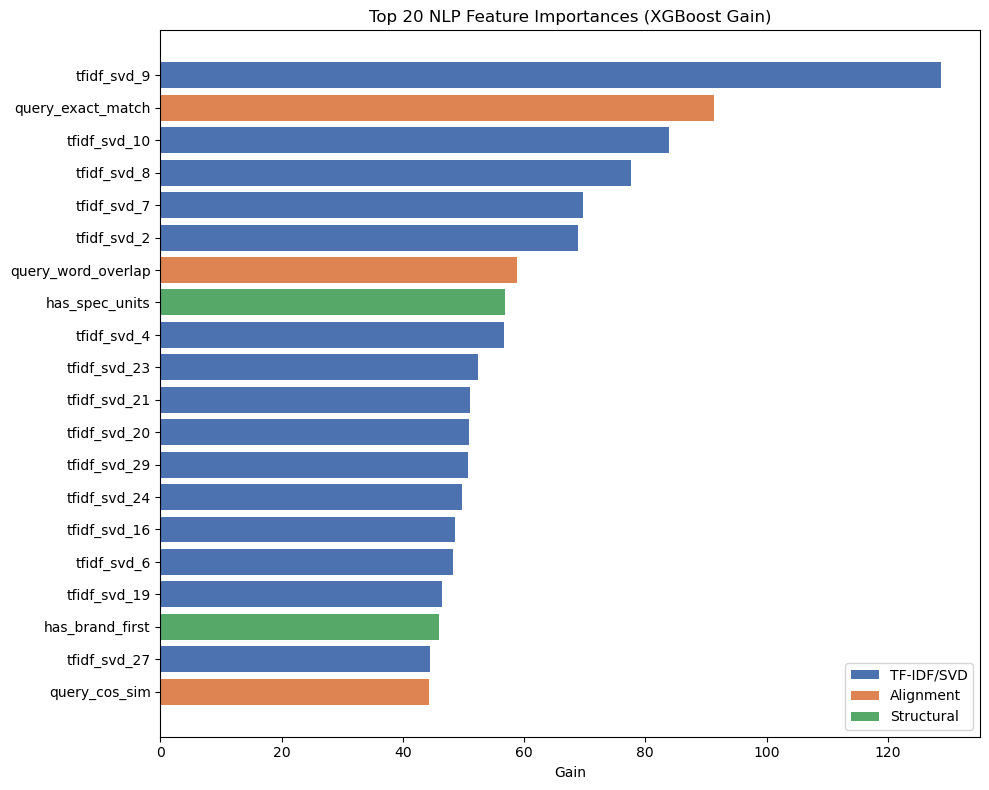

In [18]:
# Which features did XGBoost find most useful
import matplotlib.pyplot as plt

# Get feature importance from the full model (already trained above)
importance = model.get_booster().get_score(importance_type='gain')

feat_imp = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=False)

# XGBoost renames columns to f0, f1, etc.
feat_imp['feature'] = feat_imp['feature'].apply(
    lambda f: full_features[int(f.replace('f', ''))] if f.startswith('f') else f
)

print('Top 15 most important NLP features:')
print(feat_imp.head(15)[['feature', 'importance']].to_string(index=False))
print()

# Label which group each feature belongs to
def get_group(feat):
    if feat.startswith('tfidf_svd'): return 'TF-IDF/SVD'
    if feat in alignment_cols: return 'Alignment'
    return 'Structural'

feat_imp['group'] = feat_imp['feature'].apply(get_group)
group_totals = feat_imp.groupby('group')['importance'].sum().sort_values(ascending=False)
print('Total importance by feature group:')
print(group_totals.to_string())
print()

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp.head(20)
colors = top20['group'].map({'TF-IDF/SVD': '#4C72B0', 'Alignment': '#DD8452', 'Structural': '#55A868'})
ax.barh(range(len(top20)), top20['importance'], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'])
ax.invert_yaxis()
ax.set_title('Top 20 NLP Feature Importances (XGBoost Gain)')
ax.set_xlabel('Gain')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='TF-IDF/SVD'),
    Patch(facecolor='#DD8452', label='Alignment'),
    Patch(facecolor='#55A868', label='Structural'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()